In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from wordcloud import STOPWORDS

In [3]:
df=pd.read_csv('/content/archive (1).zip')
df.head()

<ipython-input-3-4155d7b18c28>:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/archive (1).zip')


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [4]:
df.isnull()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34655,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34656,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34657,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34658,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False


In [16]:
ndf=df.dropna(axis=1)
ndf.head()

,id,brand,categories,keys,manufacturer,reviews.dateSeen,reviews.sourceURLs
0,AVqkIhwDv8e3D1O-lebb,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",http://reviews.bestbuy.com/3545/5620406/review...
1,AVqkIhwDv8e3D1O-lebb,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",http://reviews.bestbuy.com/3545/5620406/review...
2,AVqkIhwDv8e3D1O-lebb,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",http://reviews.bestbuy.com/3545/5620406/review...
3,AVqkIhwDv8e3D1O-lebb,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",http://reviews.bestbuy.com/3545/5620406/review...
4,AVqkIhwDv8e3D1O-lebb,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",http://reviews.bestbuy.com/3545/5620406/review...


In [17]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  34660 non-null  object
 1   brand               34660 non-null  object
 2   categories          34660 non-null  object
 3   keys                34660 non-null  object
 4   manufacturer        34660 non-null  object
 5   reviews.dateSeen    34660 non-null  object
 6   reviews.sourceURLs  34660 non-null  object
dtypes: object(7)
memory usage: 1.9+ MB


In [18]:
ndf.isnull()

,id,brand,categories,keys,manufacturer,reviews.dateSeen,reviews.sourceURLs
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
34655,False,False,False,False,False,False,False
34656,False,False,False,False,False,False,False
34657,False,False,False,False,False,False,False
34658,False,False,False,False,False,False,False


In [20]:
text=" ".join(item for item in ndf['categories'])
print(text)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [21]:
stopwords=set(STOPWORDS)

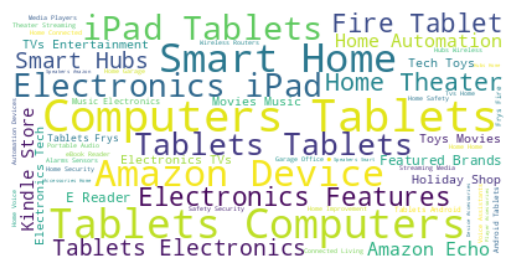

In [22]:
wordcloud=WordCloud(background_color="white").generate(text)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.margins(x=0,y=0)
plt.show()

(-0.5, 799.5, 499.5, -0.5)

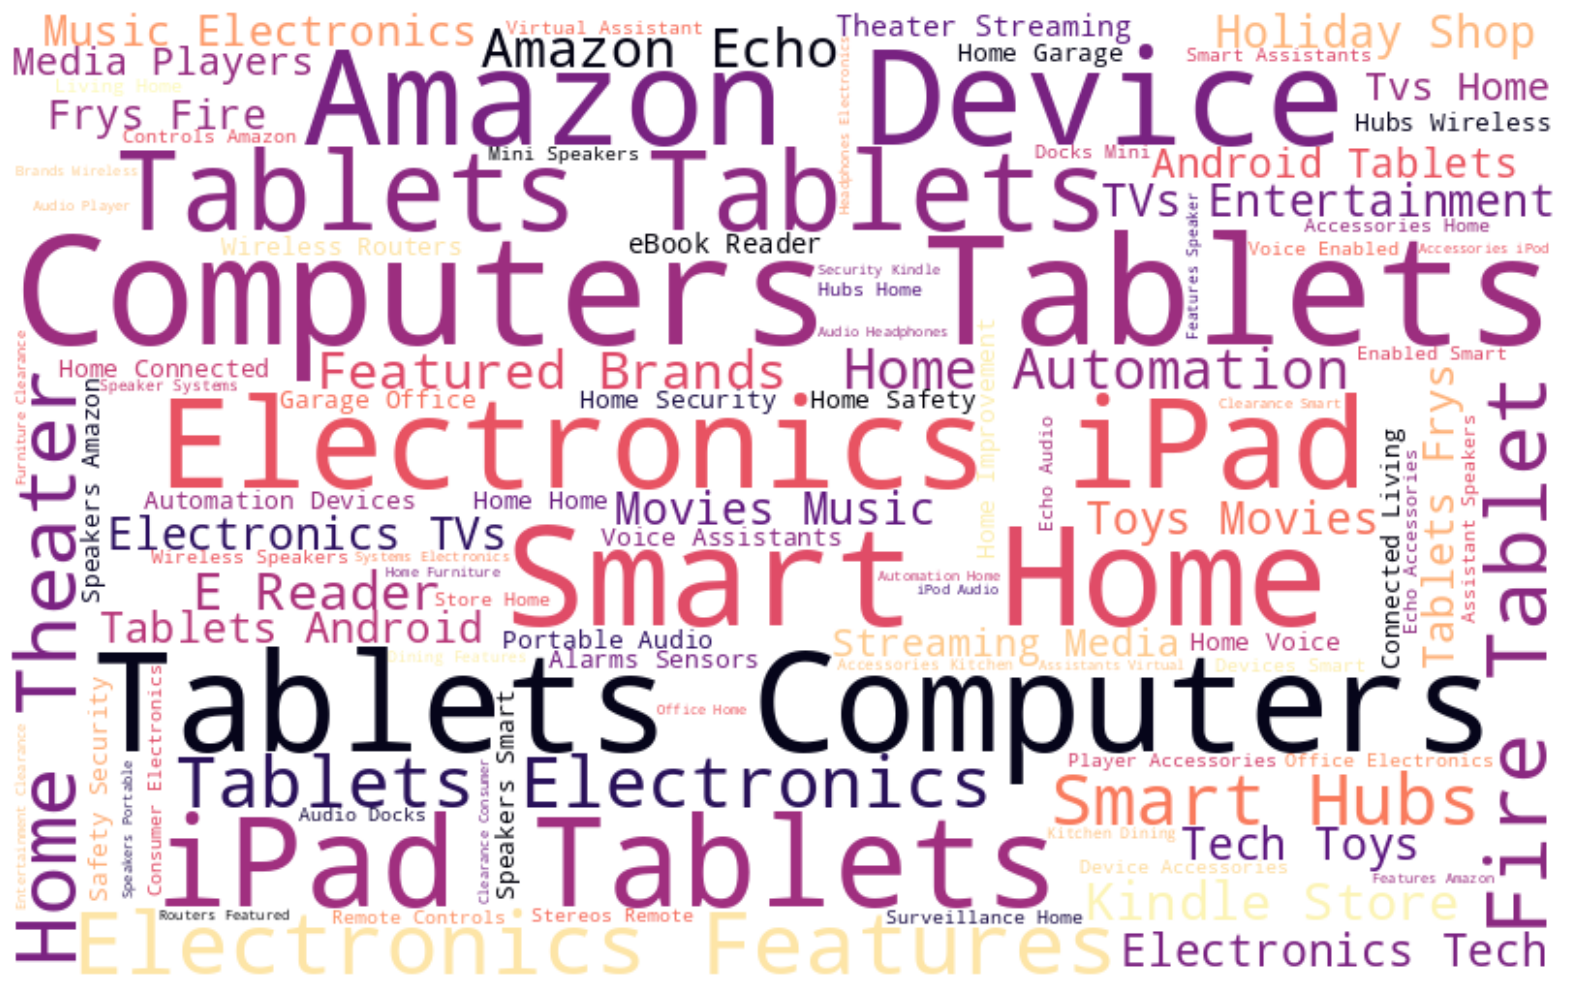

In [23]:
wordcloud=WordCloud(background_color="white",
                    max_words=100,
                    max_font_size=300,
                    width=800,
                    height=500,
                    colormap="magma").generate(text)
plt.figure(figsize=(20,20))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")